The demo shows:

- original CIFAR-10 images $x_i$;
- singularized images $\tilde{x}_i$ produced by Algorithm 1, with noise calibrated by Theorem 2;
- reconstructions $\hat{x}_i$ produced by a known-weights inversion;
- the same Algorithm 1 step applied in feature space, with memory and timing measurements.

### Algorithm 1 and Theorem 2

**Algorithm 1 (Singularized Mixup).** Given a dataset $\{(x_i, y_i)\}_{i=1}^n$ and a noise radius $r$:

1. Sample a permutation $\pi \sim \mathrm{Uniform}(S_n)$.
2. For each $i$:
   - Sample weights $w_i \sim \mathrm{Uniform}([0,1]^2)$, normalize so $\|w_i\|_1 = 1$ and $\|w_i\|_\infty \le \alpha$.
   - Sample perturbation $e_i \sim \mathrm{Uniform}(S(0, r))$.
   - $\tilde{x}_i = w_{i1}\, x_i + w_{i2}\, (x_{\pi(i)} + e_i)$.
   - $\tilde{y}_i = w_{i1}\, y_i + w_{i2}\, y_{\pi(i)}$.

**Theorem 2 (noise calibration).** With $D = \mathbb{E}\|X - X'\|_2$, $V = \mathbb{E}\|X\|_2^2$, $c = D^2/(2V) \in (0,1]$, choose $r = m_f \cdot D$ with

$$ m_f \ge \sqrt{\frac{1}{2c}\left(\frac{\alpha^2}{\tau\,(1-\alpha)^2} - 1\right)}. $$

Smaller $\tau$ means stronger privacy.

### Notation used in this notebook

| Paper symbol | Variable |
| --- | --- |
| $x_i$ | `x` |
| $y_i$ | `y` |
| $\pi$ | `pi` |
| $x_{\pi(i)}$ | `x_pi` |
| $w_i = (w_{i1}, w_{i2})$ | `w` |
| $e_i$ | `e` |
| $x_{\pi(i)} + e_i$ | `x_pi_plus_e` |
| $\tilde{x}_i$ | `x_tilde` |
| $\tilde{y}_i$ | `y_tilde` |
| $\hat{x}_i$ | `x_hat` |
| $D$ | `D` |
| $V$ | `V` |
| $c$ | `c` |
| $m_f$ | `mf` |
| $r$ | `r` |
| $\alpha$, $\tau$ | `ALPHA`, `tau` |


In [15]:
import time
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

from utils import (
    DEFAULT_SEED,
    DenseClassifier,
    IMAGENET_MEAN,
    IMAGENET_STD,
    add_noise_with_l2_norm_batch,
    build_resnet_feature_extractor,
    clamp_imagenet_normalized,
    compute_c_factor,
    cross_entropy_with_soft_targets,
    estimate_average_distance,
    estimate_per_pixel_variance_global_mean,
    get_optimal_device,
    mf_from_tau,
    mixup_batch_in_feature_space,
    sample_ball_noise,
    set_deterministic_behavior,
)

set_deterministic_behavior(DEFAULT_SEED)
device = get_optimal_device()
print(f"Device: {device}")

Device: mps


### Configuration

CIFAR-10 images for the visualization, frozen ImageNet-pretrained ResNet-18 for the feature-space pipeline.

Image-space statistics ($D$, $V$, $c$) are computed on $[0,1]$-valued images. Feature-space calibration uses ImageNet-normalized images, matching the production code.

We visualize Algorithm 1 at $\tau = 1.0$ and $\tau = 10^{-3}$.

In [16]:
DATASET = "cifar10"   # "cifar10" or "mnist"

NUM_VIS = 5
BATCH_SIZE = 128
TIMING_BATCH_SIZE = 128
ALPHA = 0.7
TAU = 1e-3
RECON_NUM_SAMPLES = 100
RECON_MSE_THRESHOLD = 0.01
STATS_SUBSET_SIZE = 1024

if DATASET == "cifar10":
    CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
    dataset_ctor = torchvision.datasets.CIFAR10
    needs_grayscale = False
elif DATASET == "mnist":
    CLASSES = [str(i) for i in range(10)]
    dataset_ctor = torchvision.datasets.MNIST
    needs_grayscale = True
else:
    raise ValueError(f"Unknown DATASET: {DATASET}")

NUM_CLASSES = len(CLASSES)

_display_steps = [transforms.Resize(224)]
if needs_grayscale:
    _display_steps.append(transforms.Grayscale(num_output_channels=3))
tfm_display = transforms.Compose(_display_steps + [transforms.ToTensor()])

tfm_resnet = transforms.Compose(_display_steps + [
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

display_train = dataset_ctor(root="./data", train=True, download=True, transform=tfm_display)
resnet_train  = dataset_ctor(root="./data", train=True, download=True, transform=tfm_resnet)
resnet_test   = dataset_ctor(root="./data", train=False, download=True, transform=tfm_resnet)

g = torch.Generator().manual_seed(DEFAULT_SEED)
vis_indices = torch.randperm(len(display_train), generator=g)[:NUM_VIS].tolist()

x_display = torch.stack([display_train[i][0] for i in vis_indices])
y = torch.tensor([display_train[i][1] for i in vis_indices])

print(f"Dataset         : {DATASET}")
print(f"Indices for x_i : {vis_indices}")
print(f"Labels  for x_i : {[CLASSES[i] for i in y.tolist()]}")

Dataset         : cifar10
Indices for x_i : [40328, 32370, 41003, 24761, 39081]
Labels  for x_i : ['airplane', 'ship', 'deer', 'ship', 'horse']


In [17]:
def to_img_np(x):
    return x.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def show_row(images, titles, figsize=(16, 3), suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(to_img_np(img))
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def show_grid(rows, row_labels, col_labels, figsize=(15, 10)):
    nrows, ncols = len(rows), len(rows[0])
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    for r in range(nrows):
        for c in range(ncols):
            axes[r, c].imshow(to_img_np(rows[r][c]))
            axes[r, c].axis("off")
            if r == 0:
                axes[r, c].set_title(col_labels[c], fontsize=11)
    plt.tight_layout()
    plt.show()


def tensor_memory_mb(tensor):
    return tensor.numel() * tensor.element_size() / (1024 ** 2)


def sync_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.synchronize()

### Algorithm 1 implementation

- `sample_permutation`: line 1, $\pi \sim \mathrm{Uniform}(S_n)$.
- `sample_weights`: line 3, $w_i \sim \mathrm{Uniform}([0,1]^2)$ with $\|w_i\|_1 = 1$, $\|w_i\|_\infty \le \alpha$ enforced by rejection.
- `sample_sphere_noise`: line 4, $e_i \sim \mathrm{Uniform}(S(0, r))$.
- `algorithm1_image_space`: lines 5–6.

In [18]:
@torch.no_grad()
def sample_permutation(n, device):
    return torch.randperm(n, device=device)


@torch.no_grad()
def sample_weights(B, alpha, device):
    w = torch.rand(B, 2, device=device)
    w = w / w.sum(dim=1, keepdim=True)
    bad = w.max(dim=1).values > alpha
    it = 0
    while bool(bad.any()) and it < 100:
        n_bad = int(bad.sum().item())
        w_new = torch.rand(n_bad, 2, device=device)
        w_new = w_new / w_new.sum(dim=1, keepdim=True)
        w[bad] = w_new
        bad = w.max(dim=1).values > alpha
        it += 1
    if bool(bad.any()):
        w[bad] = torch.tensor([alpha, 1.0 - alpha], device=device)
    return w


@torch.no_grad()
def sample_sphere_noise(x, radius):
    noise = torch.randn_like(x)
    flat = noise.flatten(1)
    norms = flat.norm(p=2, dim=1).clamp_min(1e-12)
    return noise * (radius / norms).view(-1, *([1] * (x.dim() - 1)))


@torch.no_grad()
def algorithm1_image_space(x, alpha, r, device, perm=None):
    B = x.size(0)
    x = x.to(device)
    pi = sample_permutation(B, device) if perm is None else perm.to(device)
    w = sample_weights(B, alpha, device)
    e = sample_sphere_noise(x[pi], r)
    w1 = w[:, 0].view(-1, 1, 1, 1)
    w2 = w[:, 1].view(-1, 1, 1, 1)
    x_pi_plus_e = x[pi] + e
    x_tilde = w1 * x + w2 * x_pi_plus_e
    return x_tilde, pi, w, e, x_pi_plus_e

### Original images $x_i$

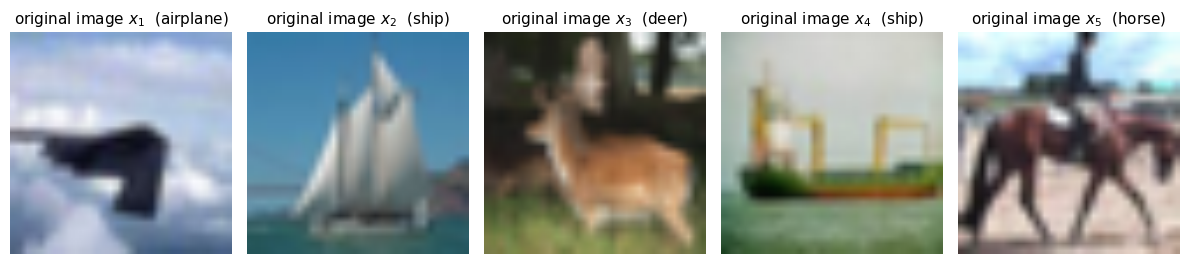

In [19]:
show_row(
    [x_display[i] for i in range(NUM_VIS)],
    [f"original image $x_{i+1}$  ({CLASSES[int(y[i])]})" for i in range(NUM_VIS)],
    figsize=(12, 3),
)

### Singularized images $\tilde{x}_i$ in image space

A singularized image is two images mixed together with some added noise.

Formally,
$$\tilde{x}_i = w_{i1}\, x_i + w_{i2}\, (x_{\pi(i)} + e_i), \qquad \tilde{y}_i = w_{i1}\, y_i + w_{i2}\, y_{\pi(i)}.$$

$D$, $V$, $c$ are estimated on a $[0,1]$ subset; $r = m_f \cdot D$ is then set at the single privacy level $\tau = 10^{-3}$.

In [20]:
display_stats_subset = Subset(display_train, list(range(STATS_SUBSET_SIZE)))
D = estimate_average_distance(
    display_stats_subset, device=device, max_images=STATS_SUBSET_SIZE, batch_size=64,
)
v_hat, d = estimate_per_pixel_variance_global_mean(
    display_stats_subset, device=device, max_images=STATS_SUBSET_SIZE, batch_size=64,
)
V = d * v_hat
c = compute_c_factor(D, v_hat, d)
mf = mf_from_tau(alpha=ALPHA, tau=TAU, c=c)
r = mf * D

print(f"D     = {D:.4f}")
print(f"V     = {V:.4f}    (d = {d}, v_hat = {v_hat:.6f})")
print(f"c     = {c:.6f}")
print(f"alpha = {ALPHA}")
print(f"tau   = {TAU:g}  ->  mf = {mf:.4f}   r = mf * D = {r:.4f}")

D     = 129.0301
V     = 9058.1499    (d = 150528, v_hat = 0.060176)
c     = 0.918993
alpha = 0.7
tau   = 0.001  ->  mf = 54.4209   r = mf * D = 7021.9325


In [21]:
torch.manual_seed(DEFAULT_SEED)
shared_pi = sample_permutation(NUM_VIS, device)

x_tilde, pi, w, e, x_pi_plus_e = algorithm1_image_space(
    x_display, alpha=ALPHA, r=r, device=device, perm=shared_pi,
)
x_tilde = x_tilde.cpu()
pi = pi.cpu()
w = w.cpu()
x_pi_plus_e = x_pi_plus_e.cpu()

# Mixed soft labels:  y_tilde_i = w_i1 * onehot(y_i) + w_i2 * onehot(y_{pi(i)})
y_onehot = torch.nn.functional.one_hot(y, num_classes=NUM_CLASSES).float()
y_tilde_img = w[:, 0:1] * y_onehot + w[:, 1:2] * y_onehot[pi]

pi_vis = pi.tolist()
x_pi = x_display[pi_vis]
y_pi = y[pi_vis]

print("pi                       :", pi_vis)
print("labels y_i               :", [CLASSES[int(l)] for l in y.tolist()])
print("labels y_{pi(i)}         :", [CLASSES[int(l)] for l in y_pi.tolist()])
print()
for i in range(NUM_VIS):
    a = CLASSES[int(y[i])]
    b = CLASSES[int(y_pi[i])]
    w1v, w2v = float(w[i, 0]), float(w[i, 1])
    nz = (y_tilde_img[i] > 0).nonzero(as_tuple=True)[0].tolist()
    parts = [f"{CLASSES[k]}: {float(y_tilde_img[i, k]):.3f}" for k in nz]
    print(f"  i={i+1}  y_i={a:<10s}  y_pi={b:<10s}  "
          f"w=({w1v:.3f}, {w2v:.3f})  ->  y_tilde = {{ {', '.join(parts)} }}")

pi                       : [0, 4, 1, 2, 3]
labels y_i               : ['airplane', 'ship', 'deer', 'ship', 'horse']
labels y_{pi(i)}         : ['airplane', 'horse', 'ship', 'deer', 'ship']

  i=1  y_i=airplane    y_pi=airplane    w=(0.520, 0.480)  ->  y_tilde = { airplane: 1.000 }
  i=2  y_i=ship        y_pi=horse       w=(0.506, 0.494)  ->  y_tilde = { horse: 0.494, ship: 0.506 }
  i=3  y_i=deer        y_pi=ship        w=(0.649, 0.351)  ->  y_tilde = { deer: 0.649, ship: 0.351 }
  i=4  y_i=ship        y_pi=deer        w=(0.374, 0.626)  ->  y_tilde = { deer: 0.626, ship: 0.374 }
  i=5  y_i=horse       y_pi=ship        w=(0.698, 0.302)  ->  y_tilde = { horse: 0.698, ship: 0.302 }


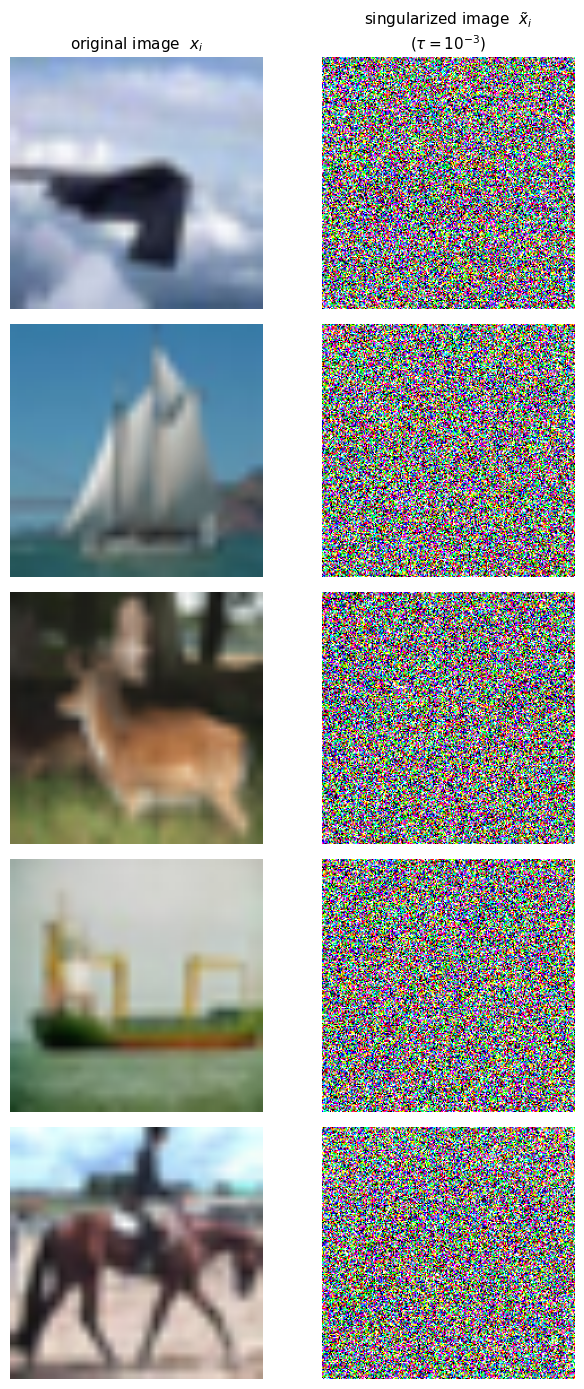

In [22]:
rows = [[x_display[i], x_tilde[i]] for i in range(NUM_VIS)]

show_grid(
    rows,
    row_labels=[f"i = {i+1}" for i in range(NUM_VIS)],
    col_labels=[
        r"original image  $x_i$",
        r"singularized image  $\tilde{x}_i$" + "\n" + r"($\tau = 10^{-3}$)",
    ],
    figsize=(7, 14),
)

### Known-weights reconstruction $\hat{x}_i$

Assume the adversary knows $w_{i1}$, $w_{i2}$, and $\pi$.

Noiseless mixup: $m_i = w_{i1} x_i + w_{i2} x_{\pi(i)}$ inverts to
$$\hat{x}_i = \frac{m_i - w_{i2}\, x_{\pi(i)}}{w_{i1}}.$$

Singularized mixup: the same inversion applied to $\tilde{x}_i$ returns
$$\hat{x}_i = x_i + \frac{w_{i2}}{w_{i1}}\, e_i,$$
amplifying the unknown noise direction. Reconstruction succeeds on the noiseless mix and fails on the singularized one.

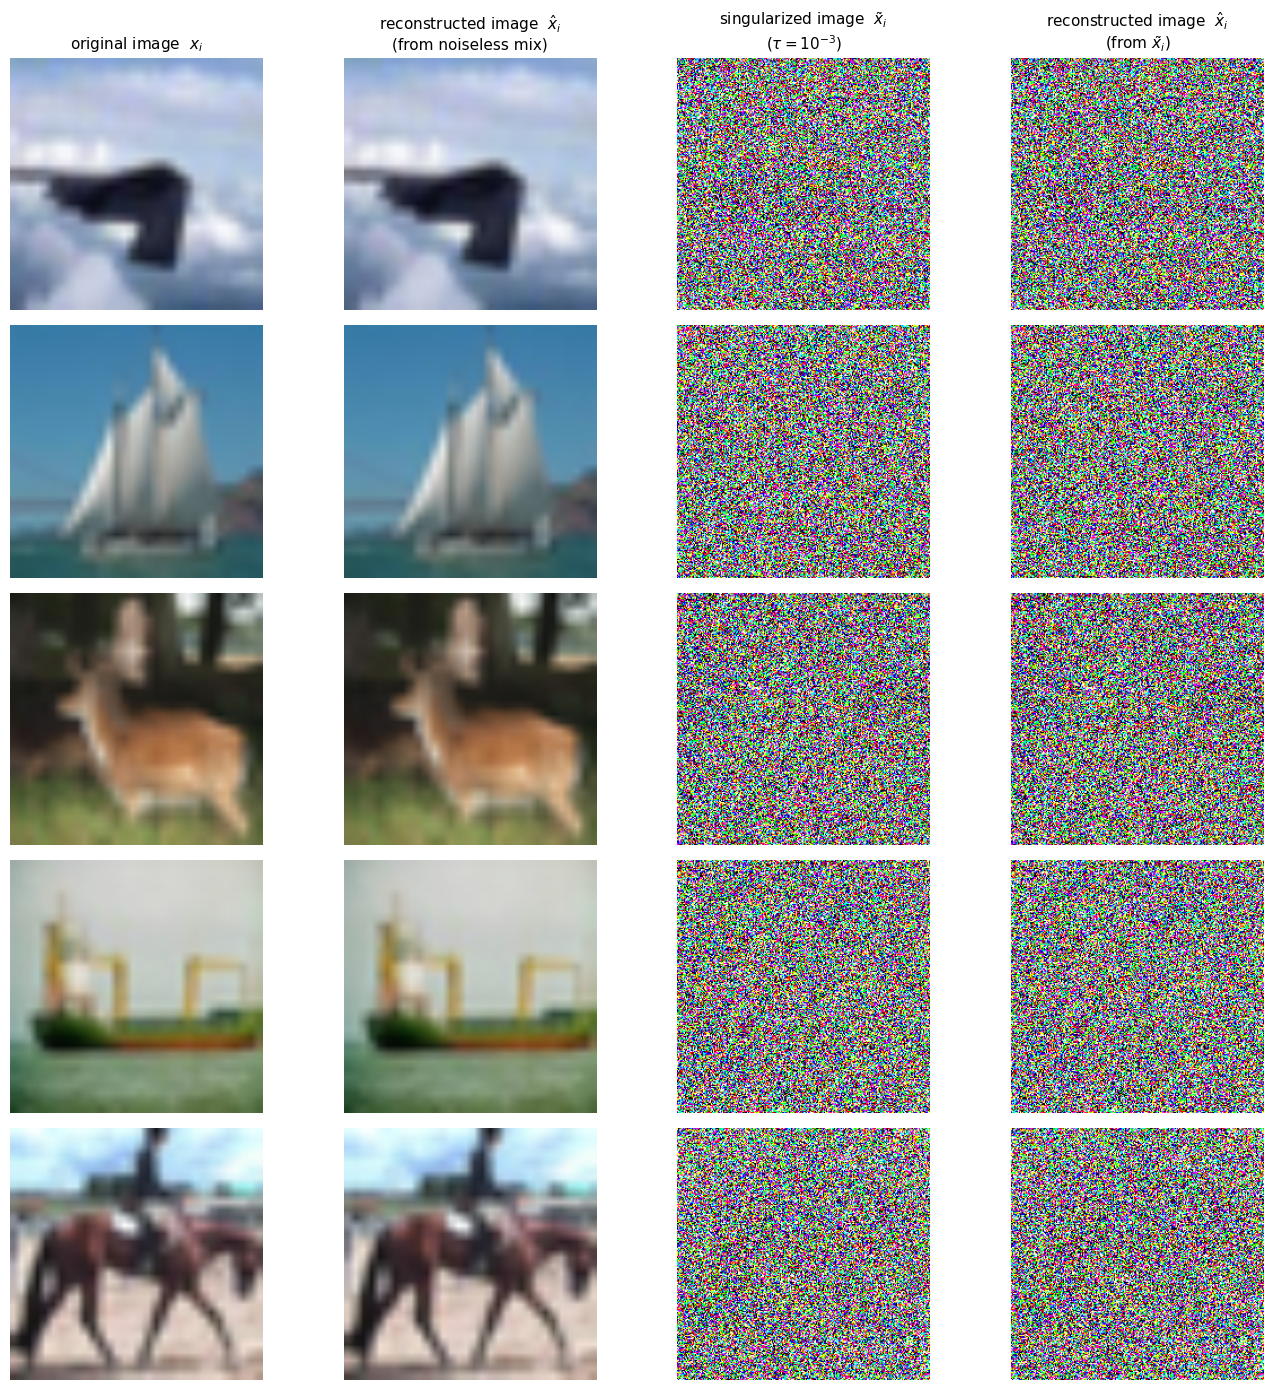

In [23]:
@torch.no_grad()
def reconstruct_known_weights(mixed, x_pi, w):
    w1 = w[:, 0].view(-1, 1, 1, 1)
    w2 = w[:, 1].view(-1, 1, 1, 1)
    return (mixed - w2 * x_pi) / w1.clamp_min(1e-6)


w1 = w[:, 0].view(-1, 1, 1, 1)
w2 = w[:, 1].view(-1, 1, 1, 1)
m_noiseless = w1 * x_display + w2 * x_pi

x_hat_noiseless = reconstruct_known_weights(m_noiseless, x_pi, w)
x_hat_singularized = reconstruct_known_weights(x_tilde, x_pi, w)

attack_rows = []
for i in range(NUM_VIS):
    attack_rows.append([
        x_display[i],
        x_hat_noiseless[i],
        x_tilde[i],
        x_hat_singularized[i],
    ])

show_grid(
    attack_rows,
    row_labels=[f"i = {i+1}" for i in range(NUM_VIS)],
    col_labels=[
        r"original image  $x_i$",
        r"reconstructed image  $\hat{x}_i$" + "\n" + r"(from noiseless mix)",
        r"singularized image  $\tilde{x}_i$" + "\n" + r"($\tau = 10^{-3}$)",
        r"reconstructed image  $\hat{x}_i$" + "\n" + r"(from $\tilde{x}_i$)",
    ],
    figsize=(14, 14),
)

### Reconstruction success rate

On $N = 100$ samples, count how often the known-weights inversion recovers the original image (success $\iff \mathrm{MSE}(\hat{x}_i, x_i) < 0.01$).

In [24]:
@torch.no_grad()
def reconstruction_success_rate(x_batch, r, alpha, threshold, device):
    N = x_batch.size(0)
    pi_b = sample_permutation(N, device)
    w_b = sample_weights(N, alpha, device)
    e_b = sample_sphere_noise(x_batch[pi_b], r)
    w1 = w_b[:, 0].view(-1, 1, 1, 1)
    w2 = w_b[:, 1].view(-1, 1, 1, 1)
    x_pi_b = x_batch[pi_b]

    m_noiseless = w1 * x_batch + w2 * x_pi_b
    x_tilde_b = w1 * x_batch + w2 * (x_pi_b + e_b)

    x_hat_noise = reconstruct_known_weights(m_noiseless.cpu(), x_pi_b.cpu(), w_b.cpu())
    x_hat_sing  = reconstruct_known_weights(x_tilde_b.cpu(),   x_pi_b.cpu(), w_b.cpu())

    mse_noise = ((x_hat_noise - x_batch.cpu()) ** 2).mean(dim=(1, 2, 3))
    mse_sing  = ((x_hat_sing  - x_batch.cpu()) ** 2).mean(dim=(1, 2, 3))

    rate_noise = float((mse_noise < threshold).float().mean().item()) * 100.0
    rate_sing  = float((mse_sing  < threshold).float().mean().item()) * 100.0
    return rate_noise, rate_sing


# Use samples disjoint from the visualization set.
metric_indices = [
    i for i in range(len(display_train)) if i not in set(vis_indices)
][:RECON_NUM_SAMPLES]
x_metric = torch.stack([display_train[i][0] for i in metric_indices]).to(device)

rate_noise, rate_sing = reconstruction_success_rate(
    x_metric, r=r, alpha=ALPHA,
    threshold=RECON_MSE_THRESHOLD, device=device,
)

print(f"Reconstruction success rate (MSE < {RECON_MSE_THRESHOLD}, N = {RECON_NUM_SAMPLES})")
print(f"  noiseless mix              : {rate_noise:6.1f} %")
print(f"  singularized (tau = {TAU:g}) : {rate_sing:6.1f} %")

Reconstruction success rate (MSE < 0.01, N = 100)
  noiseless mix              :  100.0 %
  singularized (tau = 0.001) :    0.0 %


### Singularized features $\tilde{f}_i$

Algorithm 1 applied in feature space:

$$ \tilde{f}_i = w_{i1}\, f(x_i) + w_{i2}\, \big( f(x_{\pi(i)}) + n_i \big), $$

with $n_i \sim \mathrm{Uniform}(S(0, r_{\text{feat}}))$. The feature-space radius $r_{\text{feat}}$ is set by adding image-space noise of norm $m_f \cdot D$ to a batch, pushing clean and noisy through the frozen backbone, and averaging $\|f(x) - f(x + n)\|_2$.

In [25]:
feature_extractor = build_resnet_feature_extractor("resnet18", device)
feature_extractor.eval()

resnet_stats_subset = Subset(resnet_train, list(range(STATS_SUBSET_SIZE)))
D_resnet = estimate_average_distance(
    resnet_stats_subset, device=device, max_images=STATS_SUBSET_SIZE, batch_size=64,
)
v_hat_resnet, d_resnet = estimate_per_pixel_variance_global_mean(
    resnet_stats_subset, device=device, max_images=STATS_SUBSET_SIZE, batch_size=64,
)
V_resnet = d_resnet * v_hat_resnet
c_resnet = compute_c_factor(D_resnet, v_hat_resnet, d_resnet)

TAU_FEATURE = TAU
mf_feat = mf_from_tau(alpha=ALPHA, tau=TAU_FEATURE, c=c_resnet)
r_img_feat = mf_feat * D_resnet

print(f"D     = {D_resnet:.4f}    V = {V_resnet:.4f}    c = {c_resnet:.6f}")
print(f"tau   = {TAU_FEATURE:g}  ->  mf = {mf_feat:.4f}   r = mf * D = {r_img_feat:.4f}")


@torch.no_grad()
def calibrate_feature_radius(feature_extractor, loader, mf, D, device, n_batches=4):
    target = float(mf) * float(D)
    dists = []
    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        noisy = add_noise_with_l2_norm_batch(imgs, target_norm=target)
        noisy = clamp_imagenet_normalized(noisy)
        fc = feature_extractor(imgs).flatten(1)
        fn = feature_extractor(noisy).flatten(1)
        dists.append((fc - fn).norm(p=2, dim=1))
    return float(torch.cat(dists).mean().item())


calib_loader = DataLoader(resnet_stats_subset, batch_size=64, shuffle=False)
r_feat = calibrate_feature_radius(
    feature_extractor, calib_loader, mf_feat, D_resnet, device, n_batches=4,
)
print(f"r_feat = {r_feat:.4f}")

D     = 568.5927    V = 176852.1075    c = 0.914034
tau   = 0.001  ->  mf = 54.5683   r = mf * D = 31027.1594
r_feat = 268.3900


In [26]:
x_resnet = torch.stack([resnet_train[i][0] for i in vis_indices])
y_resnet = torch.tensor([resnet_train[i][1] for i in vis_indices])

with torch.no_grad():
    f_x = feature_extractor(x_resnet.to(device)).detach().cpu()

f_tilde_flat, y_tilde = mixup_batch_in_feature_space(
    feature_extractor, x_resnet, y_resnet, device, r_feat, num_classes=NUM_CLASSES,
)
f_tilde = f_tilde_flat.detach().cpu().view_as(f_x)

print(f"features f(x_i) shape          : {tuple(f_x.shape)}")
print(f"singularized features f_tilde  : {tuple(f_tilde_flat.shape)}")
print()
print("mixed soft labels y_tilde (non-zero entries shown):")
for i in range(NUM_VIS):
    row = y_tilde[i].detach().cpu()
    nz = (row > 0).nonzero(as_tuple=True)[0].tolist()
    parts = [f"{CLASSES[k]}: {float(row[k]):.3f}" for k in nz]
    print(f"  i={i+1}  y_tilde = {{ {", ".join(parts)} }}")

features f(x_i) shape          : (5, 512, 7, 7)
singularized features f_tilde  : (5, 25088)

mixed soft labels y_tilde (non-zero entries shown):
  i=1  y_tilde = { airplane: 0.481, horse: 0.519 }
  i=2  y_tilde = { airplane: 0.343, ship: 0.657 }
  i=3  y_tilde = { deer: 0.416, ship: 0.584 }
  i=4  y_tilde = { deer: 0.671, ship: 0.329 }
  i=5  y_tilde = { horse: 0.331, ship: 0.669 }


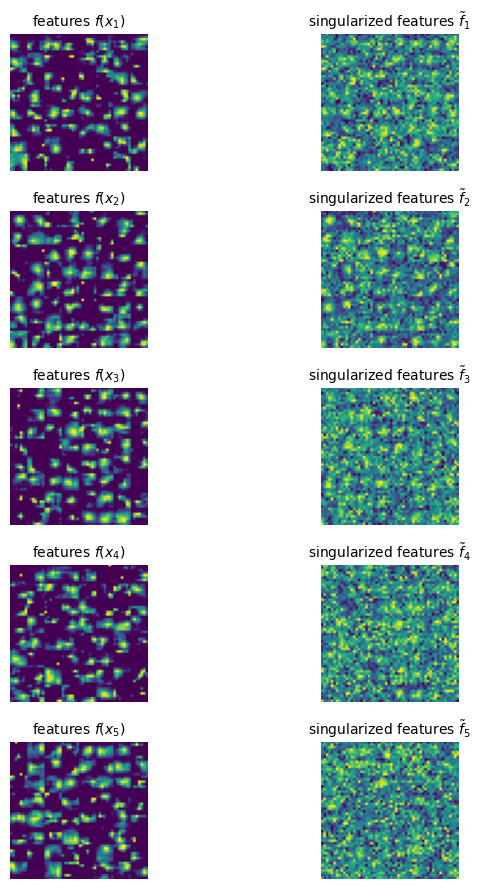

In [27]:
def feature_grid(feat_map, max_channels=64):
    fmap = feat_map.detach().cpu()[:max_channels]
    c, h, w = fmap.shape
    grid_size = int(np.ceil(np.sqrt(c)))
    grid = torch.zeros(grid_size * h, grid_size * w)
    for idx in range(c):
        ch = fmap[idx]
        ch = ch - ch.min()
        denom = ch.max().clamp_min(1e-12)
        ch = ch / denom
        r = idx // grid_size
        col = idx % grid_size
        grid[r*h:(r+1)*h, col*w:(col+1)*w] = ch
    return grid.numpy()


fig, axes = plt.subplots(NUM_VIS, 2, figsize=(8, 9))
for i in range(NUM_VIS):
    axes[i, 0].imshow(feature_grid(f_x[i]), cmap="viridis")
    axes[i, 0].set_title(rf"features $f(x_{{{i+1}}})$", fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(feature_grid(f_tilde[i]), cmap="viridis")
    axes[i, 1].set_title(rf"singularized features $\tilde{{f}}_{{{i+1}}}$", fontsize=10)
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

### Memory footprint

In [28]:
with torch.no_grad():
    f_x_flat = f_x.flatten(1)

memory_rows = [
    ("original image  (x_i)",              tuple(x_display.shape),                              tensor_memory_mb(x_display)),
    ("singularized image  (x_tilde_i)",    tuple(x_tilde.shape),         tensor_memory_mb(x_tilde)),
    ("features  (f(x_i))",                 tuple(f_x_flat.shape),                                tensor_memory_mb(f_x_flat)),
    ("singularized features  (f_tilde_i)", tuple(f_tilde_flat.shape),                            tensor_memory_mb(f_tilde_flat.detach().cpu())),
    ("mixed soft labels  (y_tilde_i)",     tuple(y_tilde.shape),                                 tensor_memory_mb(y_tilde.detach().cpu())),
]

print(f"{'Tensor':<38} {'Shape':<24} {'Memory (MB)':>12}")
print("-" * 78)
for name, shape, mb in memory_rows:
    print(f"{name:<38} {str(shape):<24} {mb:>12.4f}")

Tensor                                 Shape                     Memory (MB)
------------------------------------------------------------------------------
original image  (x_i)                  (5, 3, 224, 224)               2.8711
singularized image  (x_tilde_i)        (5, 3, 224, 224)               2.8711
features  (f(x_i))                     (5, 25088)                     0.4785
singularized features  (f_tilde_i)     (5, 25088)                     0.4785
mixed soft labels  (y_tilde_i)         (5, 10)                        0.0002


### Per-batch timing

10 epochs on a 512-sample subset, mean $\pm$ std per batch.

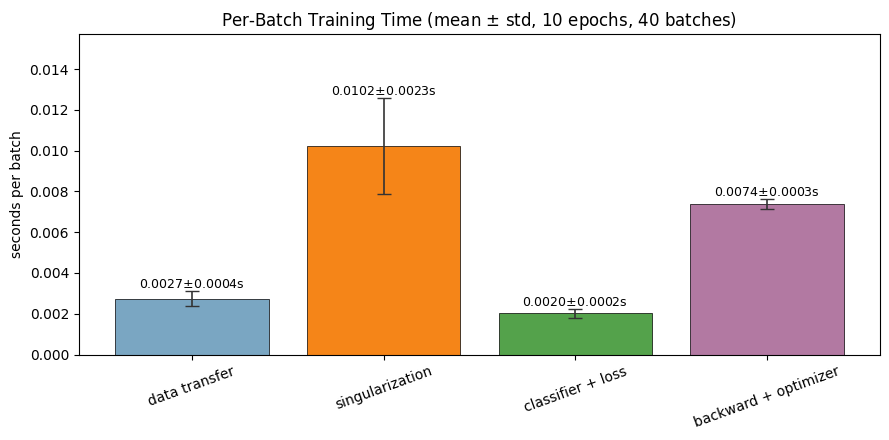

In [29]:
TIMING_EPOCHS = 10
TIMING_SUBSET_SIZE = 512


@torch.no_grad()
def infer_embedding_dim(feature_extractor, dataset):
    x, _ = dataset[0]
    fmap = feature_extractor(x.unsqueeze(0).to(device))
    return fmap.flatten(1).size(1)


def timed_one_batch(feature_extractor, classifier, optimizer, imgs, labels, radius):
    timings = OrderedDict()

    sync_if_needed()
    t0 = time.perf_counter()
    imgs = imgs.to(device)
    labels = labels.to(device)
    sync_if_needed()
    timings["data transfer"] = time.perf_counter() - t0

    feature_extractor.eval()
    sync_if_needed()
    t0 = time.perf_counter()
    with torch.no_grad():
        fmap = feature_extractor(imgs)
        feats = fmap.flatten(1)
    sync_if_needed()
    timings["feature extraction"] = time.perf_counter() - t0

    sync_if_needed()
    t0 = time.perf_counter()
    bsz, dim = feats.shape
    pi = sample_permutation(bsz, device)
    w = sample_weights(bsz, ALPHA, device)
    w1 = w[:, 0].view(bsz, 1)
    w2 = w[:, 1].view(bsz, 1)
    noise = sample_ball_noise((bsz, dim), radius, device=device)
    f_tilde_batch = w1 * feats + w2 * (feats[pi] + noise)
    y_tilde_batch = torch.zeros(bsz, NUM_CLASSES, device=device)
    y_tilde_batch.scatter_add_(1, labels.view(-1, 1), w1)
    y_tilde_batch.scatter_add_(1, labels[pi].view(-1, 1), w2)
    sync_if_needed()
    timings["singularization"] = time.perf_counter() - t0

    classifier.train()
    optimizer.zero_grad(set_to_none=True)
    sync_if_needed()
    t0 = time.perf_counter()
    outputs = classifier(f_tilde_batch)
    loss = cross_entropy_with_soft_targets(outputs, y_tilde_batch)
    sync_if_needed()
    timings["classifier + loss"] = time.perf_counter() - t0

    sync_if_needed()
    t0 = time.perf_counter()
    loss.backward()
    optimizer.step()
    sync_if_needed()
    timings["backward + optimizer"] = time.perf_counter() - t0

    return timings, float(loss.item())


timing_subset = Subset(resnet_train, list(range(TIMING_SUBSET_SIZE)))
timing_loader = DataLoader(timing_subset, batch_size=TIMING_BATCH_SIZE, shuffle=True)

embedding_dim = infer_embedding_dim(feature_extractor, resnet_train)
classifier = DenseClassifier(embedding_dim, NUM_CLASSES).to(device)
optimizer = optim.SGD(classifier.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

warm_imgs, warm_labels = next(iter(timing_loader))
for _ in range(2):
    _ = timed_one_batch(
        feature_extractor, classifier, optimizer, warm_imgs, warm_labels, r_feat,
    )

component_names = ["data transfer", "feature extraction", "singularization",
                   "classifier + loss", "backward + optimizer"]
samples = {name: [] for name in component_names}
n_batches = 0
for epoch in range(TIMING_EPOCHS):
    for imgs, labels in timing_loader:
        timings, _ = timed_one_batch(
            feature_extractor, classifier, optimizer, imgs, labels, r_feat,
        )
        for name in component_names:
            samples[name].append(timings[name])
        n_batches += 1

stats = OrderedDict()
for name in component_names:
    arr = np.asarray(samples[name], dtype=np.float64)
    stats[name] = (arr.mean(), arr.std(ddof=1) if arr.size > 1 else 0.0)

plot_names = [n for n in component_names if n != "feature extraction"]
means = [stats[n][0] for n in plot_names]
stds = [stats[n][1] for n in plot_names]
colors = ["#7aa6c2", "#f58518", "#54a24b", "#b279a2"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    plot_names, means, yerr=stds, capsize=5,
    color=colors[:len(plot_names)], edgecolor="black", linewidth=0.5,
    error_kw={"elinewidth": 1.2, "ecolor": "#333"},
)
ax.set_ylabel("seconds per batch")
ax.set_title(
    r"Per-Batch Training Time (mean $\pm$ std, "
    + str(TIMING_EPOCHS) + " epochs, " + str(n_batches) + " batches)"
)
ax.tick_params(axis="x", rotation=20)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s, f"{m:.4f}" + r"$\pm$" + f"{s:.4f}s",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.25)
plt.tight_layout()
plt.show()


### Takeaway

Algorithm 1 is a small tensor operation. With known $w_{i1}$, $w_{i2}$, $\pi$, noiseless mixup inverts algebraically; singularized mixup returns $x_i + (w_{i2}/w_{i1})\, e_i$, and the noise grows with $r = m_f(\tau)\, D$ from Theorem 2.